## Introduction 

In this script, the straightness per ward is computed. The straightness per ward for only the drivable roads for Chennai is computed.

## Reading in the Python libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import momepy
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [5]:
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_chennai" / "chennai_graphml_drive.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
# WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [6]:
## Detailed wards
df_inpath = PROCESSED_DIR / "chennai_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\chennai_fix_mapshaper.shp


In [7]:
df = gpd.read_file(df_inpath)
df.head()

,Name,zone_id,zone_name,geometry
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584..."
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ..."
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ..."
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13...."
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318..."


In [8]:
print(f'There are {df.shape[0]} wards in the dataset.')

There are 200 wards in the dataset.


Reading in the entire Chennai network data that we had downloaded earlier as again we will "truncate" the network to the different street networks at the ward level:

In [9]:
G = ox.io.load_graphml(path_graphml)

In [10]:
G.graph["crs"]

'epsg:4326'

In [11]:
df.crs.to_epsg()

4326

## Computing street straightness at the ward level

In [15]:
results = pd.DataFrame(columns=['Name', 'zone_id', 'zone_name', 'straightness'])
results

,Name,zone_id,zone_name,straightness


In [16]:
## for ward in tqdm(range(0,5), desc="Processing wards"):
for ward in tqdm(range(0,len(df)), desc = "Processing wards"):

    ## print(f'Processing the {ward} ward.')

    Name = df['Name'].iloc[ward]
    zone_id = df['zone_id'].iloc[ward]
    zone_name = df['zone_name'].iloc[ward]
    
    ## print(name_ward)

    df_ward = df.iloc[[ward]]

    ## ward_geometry = df.iloc[ward,:].geometry
    ward_geometry = df_ward.geometry.iloc[0]

    ## https://docs.momepy.org/en/stable/user_guide/simple/shape.html#Street-network-shapes
    G_clipped = ox.truncate.truncate_graph_polygon(G, ward_geometry)

    streets_graph = ox.projection.project_graph(G_clipped)

    edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
    )

    primal = momepy.gdf_to_nx(edges, approach="primal")

    primal = momepy.straightness_centrality(primal)

    nodes = momepy.nx_to_gdf(primal, lines=False)


    straightness_mean = nodes['straightness'].mean()

    ## print(straightness_mean)

    results.loc[ward] = [
        Name,
        zone_id,
        zone_name,
        straightness_mean
    ]
    

Processing wards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [12:53<00:00,  3.87s/it]


In [17]:
results

,Name,zone_id,zone_name,straightness
0,168,13,Adyar,0.681339
1,169,13,Adyar,0.602852
2,170,13,Adyar,0.687663
3,171,13,Adyar,0.699583
4,174,13,Adyar,0.717740
...,...,...,...,...
195,110,9,Teynampet,0.654636
196,161,12,Alandur,0.693922
197,160,12,Alandur,0.740252
198,195,15,Sholinganallur,0.619730


In [18]:
print(f'The mean of the straigthness across the wards is {results["straightness"].mean()}.')
print(f'The minimum of the straigthness across the wards is {results["straightness"].min()}.')
print(f'The maximum of the straigthness across the wards is {results["straightness"].max()}.')

The mean of the straigthness across the wards is 0.7037452950417473.
The minimum of the straigthness across the wards is 0.5262524796666604.
The maximum of the straigthness across the wards is 0.8019433113986958.


In [19]:
## Save this:
results_path = PROCESSED_DIR / "results_chennai_straightness_all_roads_drive.csv"

results.to_csv(results_path)

In [20]:
top10_highest = (
    results
    .sort_values(by='straightness', ascending=False)
    .head(10)
)
top10_highest

,Name,zone_id,zone_name,straightness
125,60,5,Royapuram,0.801943
145,38,4,Tondiarpet,0.800138
96,69,6,Thiru-Vi-Ka. Nagar,0.799855
65,20,2,Manali,0.792647
122,57,5,Royapuram,0.780030
117,50,5,Royapuram,0.778468
120,55,5,Royapuram,0.777371
127,62,5,Royapuram,0.776536
141,141,10,Kodambakkam,0.774278
83,164,12,Alandur,0.773428


In [21]:
top10_lowest = (
    results
    .sort_values(by='straightness', ascending=True)
    .head(10)
)
top10_lowest

,Name,zone_id,zone_name,straightness
27,191,14,Perungudi,0.526252
46,106,8,Anna Nagar,0.548963
85,159,12,Alandur,0.559323
109,146,11,Valasaravakkam,0.559603
179,31,3,Madhavaram,0.570730
13,193,15,Sholinganallur,0.590356
43,118,9,Teynampet,0.594192
10,176,13,Adyar,0.595295
17,200,15,Sholinganallur,0.600072
1,169,13,Adyar,0.602852


In [22]:
df_merged = df.merge(results, on = 'Name')
df_merged

,Name,zone_id_x,zone_name_x,geometry,zone_id_y,zone_name_y,straightness
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",13,Adyar,0.681339
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",13,Adyar,0.602852
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",13,Adyar,0.687663
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",13,Adyar,0.699583
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",13,Adyar,0.717740
...,...,...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",9,Teynampet,0.654636
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",12,Alandur,0.693922
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",12,Alandur,0.740252
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",15,Sholinganallur,0.619730


In [23]:
df_merged = df_merged[['Name', 'zone_id_x', 'zone_name_x', 'geometry', 'straightness']]
df_merged

,Name,zone_id_x,zone_name_x,geometry,straightness
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",0.681339
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",0.602852
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",0.687663
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",0.699583
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",0.717740
...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",0.654636
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",0.693922
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",0.740252
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",0.619730


In [24]:
# Rename the columns
df_merged = df_merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name'
})

In [25]:
## Path to save the figure:
fig_path = IMAGES_DIR / 'straightness_all_roads_chennai_drive.png'

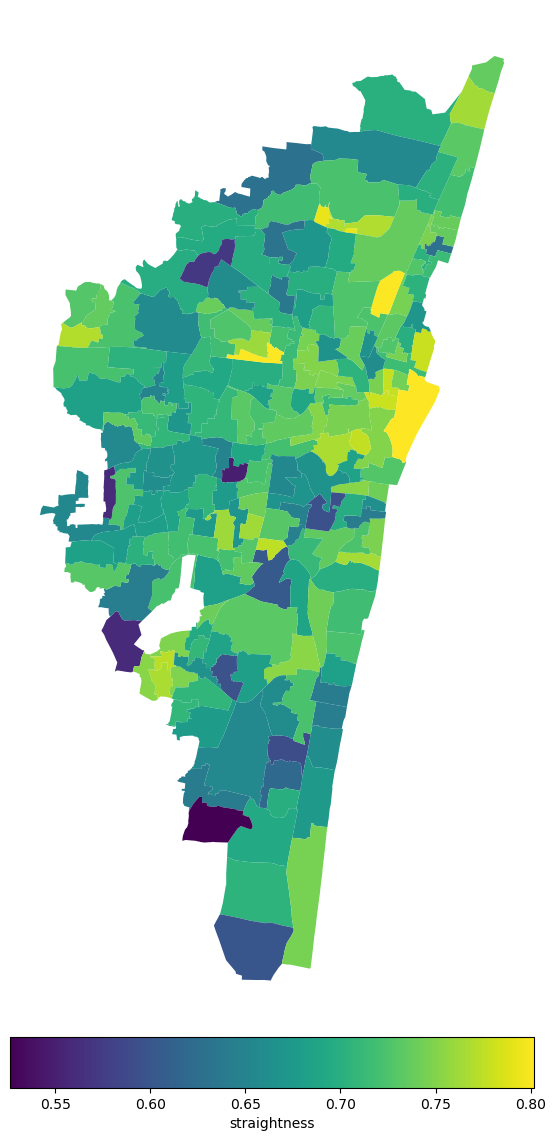

In [26]:
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_merged.plot(
    column="straightness",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "straightness", "orientation": "horizontal"},
)
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()